#**Desafio 4 - Estimativa de Salários**



> # Alunos



*  Matheus Gomes Pedroza (RA: 1998912)
*  Guilherme Dorce de Britto (RA:1991866)
* Rodrigo Shinji Yamashita (RA: 2001443)







# **Etapa 1 | Importações**




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as skt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Modelos

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score






# **Etapa 2 | Carregamento de Dados**




In [2]:
import kagglehub

path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
dataset = pd.read_csv(f'{path}/adult.csv')

100%|██████████| 652k/652k [00:00<00:00, 674kB/s]

Extracting files...




# **Etapa 3 | Análise Exploratória (EDA)**

---






## Distribuição de renda



In [3]:
dataset['income'].value_counts() # Quantidade de pessoas que ganham mais ou menos/igual de 50k no dataset

,count
income,
<=50K,37155
>50K,11687


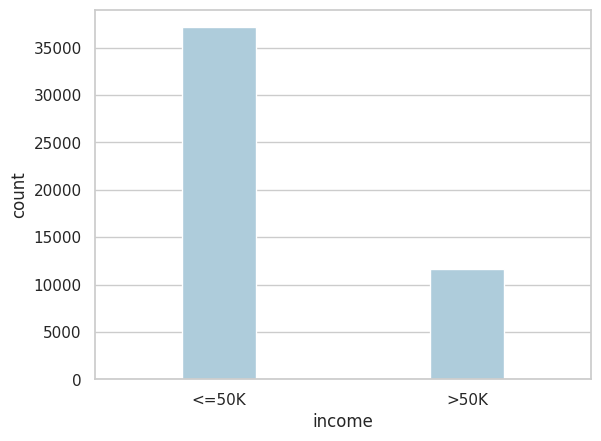

<Figure size 700x400 with 0 Axes>

In [4]:
sns.set_theme(style="whitegrid")
sns.despine()
sns.set_palette("Paired")
sns.countplot(x='income', data=dataset, width=0.3)
plt.figure(figsize=(7,4))
plt.show()

# Boxplot's

---



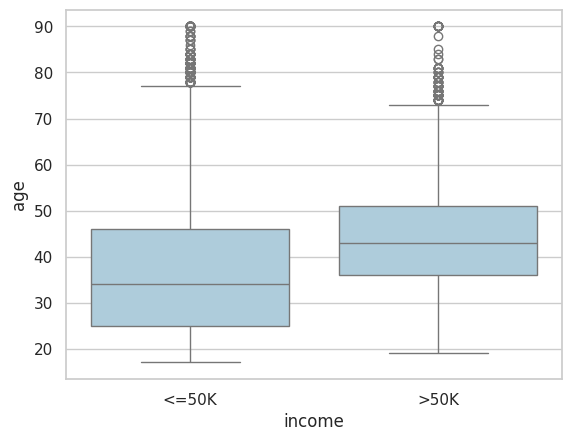

In [5]:
# Boxplot de Idades

sns.boxplot(x='income', y='age', data=dataset)
plt.show()



> Análise de horas trabalhadas por tipo de Trabalho






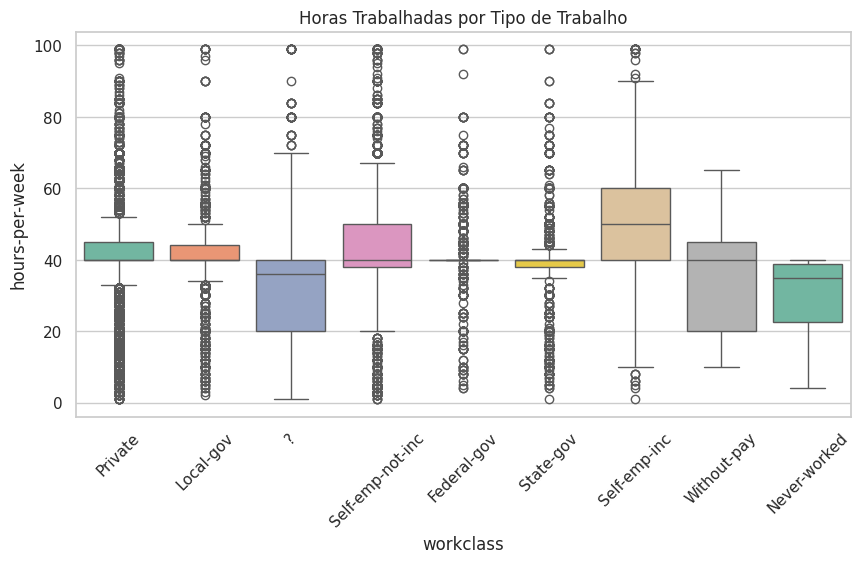

In [6]:
# Boxplot de Horas Trabalhadas
plt.figure(figsize=(10,5))
sns.boxplot(x='workclass', y='hours-per-week', data=dataset, palette='Set2', hue='workclass')
plt.xticks(rotation=45)
plt.title('Horas Trabalhadas por Tipo de Trabalho')
plt.show()



> Análise de horas trabalhadas por tipo de Educação






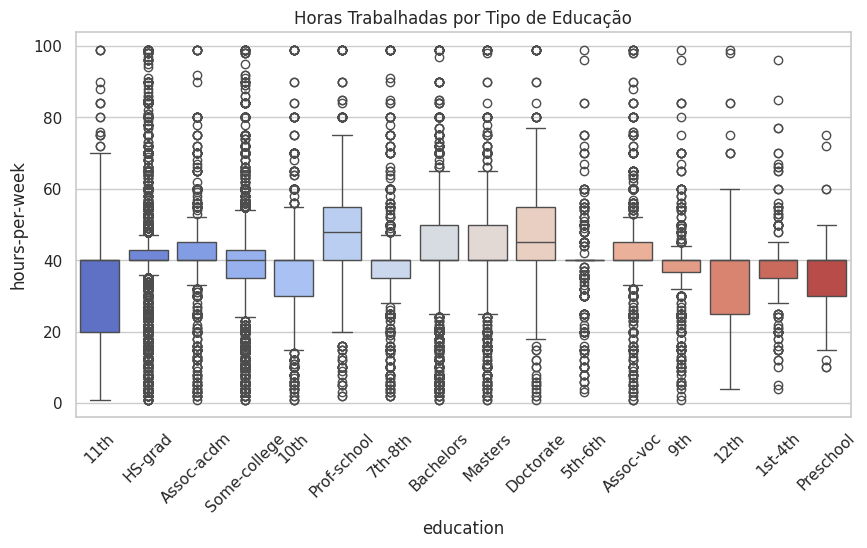

In [7]:
# Boxplot de Horas Trabalhadas
plt.figure(figsize=(10,5))
sns.boxplot(x='education', y='hours-per-week', data=dataset, palette='coolwarm', hue='education')
plt.xticks(rotation=45)
plt.title('Horas Trabalhadas por Tipo de Educação')
plt.show()

# Gráficos

---



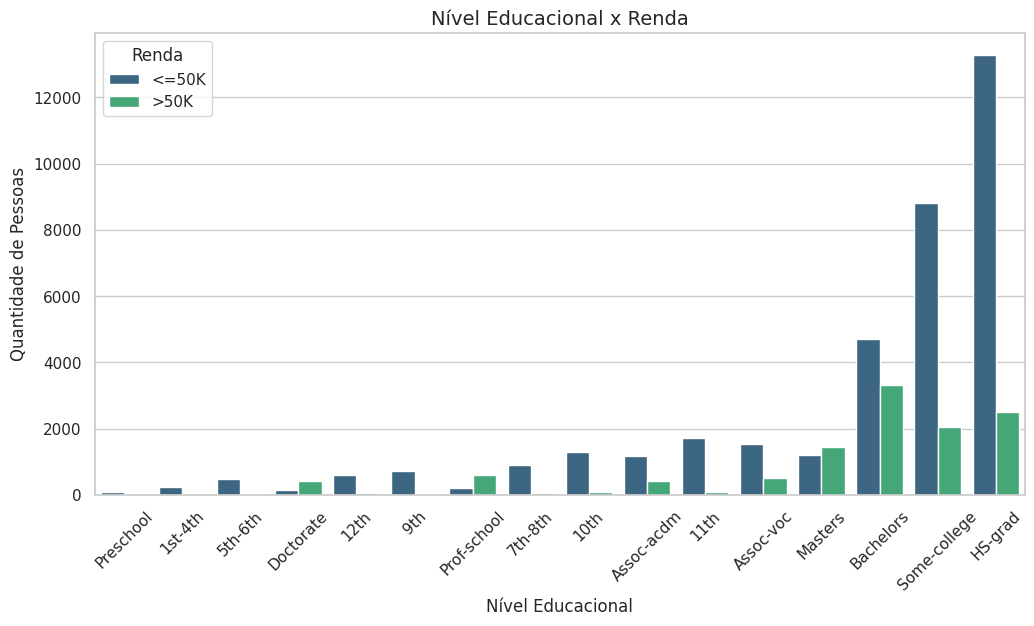

In [8]:
plt.figure(figsize=(12,6))

ordem = dataset.groupby('education')['income'].count().sort_values().index

sns.countplot(x='education',hue='income',data=dataset, palette='viridis', order=ordem,)
plt.title('Nível Educacional x Renda', fontsize=14)
plt.xlabel('Nível Educacional')
plt.ylabel('Quantidade de Pessoas')

plt.xticks(rotation=45)
plt.legend(title='Renda')
plt.show()

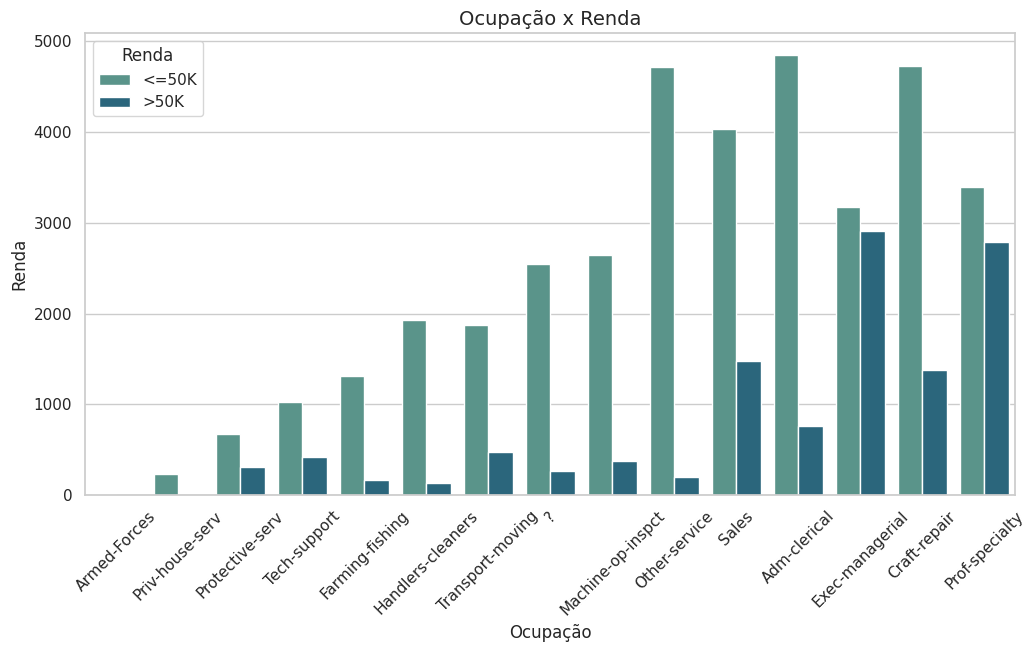

In [9]:
plt.figure(figsize=(12,6))

ordem = dataset.groupby('occupation')['income'].count().sort_values().index

sns.countplot(x='occupation', hue='income' ,data=dataset, order=ordem, palette='crest')
plt.xticks(rotation=45)
plt.title('Ocupação x Renda', fontsize=14)
plt.xlabel('Ocupação')
plt.ylabel('Renda')
plt.legend(title='Renda')
plt.show()

# Scatter

---



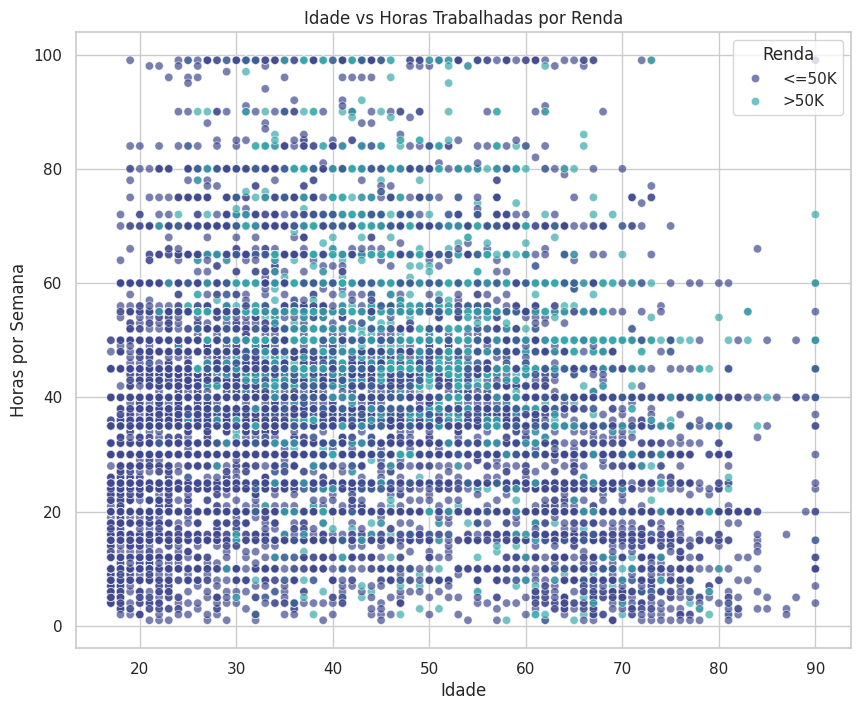

In [10]:
plt.figure(figsize=(10,8))

sns.scatterplot(x='age',y='hours-per-week',hue='income',data=dataset,palette='mako',alpha=0.7)

plt.title('Idade vs Horas Trabalhadas por Renda')
plt.xlabel('Idade')
plt.ylabel('Horas por Semana')
plt.legend(title='Renda')

plt.show()



# **Etapa 4 | Pré-Processamento de Dados**




---





## Valores Missing (?)


In [11]:
dataset.replace('?', np.nan, inplace=True) # Transformando valores missing em NaN, pois Pandas não identifica (?)
dataset.isnull().sum() # Dataset possui muitos valores faltantes

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [12]:
dataset.dropna(inplace=True)
dataset.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0




> Valores ausentes foram convertidos para Nan e removidos do dataset, melhorando a qualidade do treinamento de modelos posteriormente.



## Removendo fnlwgt (não informativo)

---



In [13]:
dataset.drop('fnlwgt', axis=1, inplace=True)
dataset.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')



> A coluna 'fnlwgt' foi removida do dataset, pis não é informativa e irrelevante para o aprendizado dos modelos.



## Encoding / Labels

---





> Binárias



In [14]:
for col in dataset.select_dtypes(include='object').columns:
    print(col, dataset[col].nunique())

# Aqui vemos quais colunas possuem apenas dois valores e são TEXTO
# Facilitando a transformação para binários

workclass 7
education 16
marital-status 7
occupation 14
relationship 6
race 5
gender 2
native-country 41
income 2


In [15]:
dataset['income'] = dataset['income'].map({'<=50K': 0, '>50K': 1})
dataset['income'].head()

# Coluna Income transformada em Binária

,income
0,0
1,0
2,1
3,1
5,0


In [16]:
dataset['gender'] = dataset['gender'].map({'Male': 0, 'Female': 1})
dataset['gender'].tail()

# Coluna Gender transformada em Binária

,gender
48837,1
48838,0
48839,1
48840,0
48841,1


## OneHot / Nominais

---



In [17]:
dataset = pd.get_dummies(dataset, drop_first=True)
dataset.dtypes

,0
age,int64
educational-num,int64
gender,int64
capital-gain,int64
capital-loss,int64
...,...
native-country_Thailand,bool
native-country_Trinadad&Tobago,bool
native-country_United-States,bool
native-country_Vietnam,bool




> Categorias nominais foram transformadas utilizando One-Hot Encoding, onde cada valor é uma nova coluna com valor binário. Para utilização adequada nos modelos.



# Feature Extra - Capital Gain

---



In [18]:
dataset['has_capital_gain'] = dataset['capital-gain'] > 0
dataset['has_capital_loss'] = dataset['capital-loss'] > 0

# Criando novas colunas que verificam se tem 'capital_gain' e 'capital_loss'
# Atribuindo True e False e posteriormente binário

dataset['has_capital_gain'] = dataset['has_capital_gain'].astype(int)
dataset['has_capital_loss'] = dataset['has_capital_loss'].astype(int)

dataset[['has_capital_gain', 'has_capital_loss']].head()

,has_capital_gain,has_capital_loss
0,0,0
1,0,0
2,0,0
3,1,0
5,0,0




> Implementamos uma feature extra, como dica, onde transformamos Capital Gain em colunas binárias para que os modelos entendam se há presença de Capital Gain, facilitando identificação de padrões.



## Divisão Treino/Val/Teste com estratificação

---





> Separando X (feature) e y (targets)


In [19]:
X = dataset.drop('income', axis=1) # Features (dados)
y = dataset['income'] # Targets (respostas)



> Dividindo 60% (Treino) | 40% (Temporário)



In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.4, stratify=y, random_state=42)

# X -> Entrada
# y -> Saída
# test_size=0.4 -> Indica que será divido em 40%
# stratify=y -> Manter a proporção
# random_state=42 -> Gera os mesmo dados toda vez que rodar



> Dividindo Dados Temporários - 50% (Validação) | 50% (Teste





In [21]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5,stratify=y_temp,random_state=42)

# X -> Entrada
# y -> Saída
# test_size=0.5 -> Indica que será divido em 50%
# stratify=y_temp -> Manter a proporção
# random_state=42 -> Gera os mesmo dados toda vez que rodar

## Normalização

---


In [22]:
scaler = StandardScaler()

num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Aprende média e desvio padrão usando apenas os dados de treino
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Aplica a mesma transformação aos dados de validação
X_val[num_cols] = scaler.transform(X_val[num_cols])

# Aplica a mesma transformação aos dados de teste
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,has_capital_gain,has_capital_loss
5769,0.334437,-0.438235,1,-0.147906,-0.217254,-0.085108,False,True,False,False,...,False,False,False,False,False,True,False,False,0,0
43335,-0.798262,-0.048710,1,-0.147906,-0.217254,-0.085108,False,True,False,False,...,False,False,False,False,False,True,False,False,0,0
7759,-0.118643,-0.438235,0,-0.147906,-0.217254,-0.085108,False,True,False,False,...,False,False,False,False,False,True,False,False,0,0
7202,-0.873775,-0.438235,0,-0.147906,-0.217254,-0.085108,False,True,False,False,...,False,False,False,False,False,True,False,False,0,0
34691,0.334437,-0.438235,0,-0.147906,-0.217254,0.744540,False,False,False,True,...,False,False,False,False,False,True,False,False,0,0


A normalização foi aplicada após a divisão dos dados para evitar data leakage.
O StandardScaler foi ajustado apenas com os dados de treino usando fit_transform.
Nos conjuntos de validação e teste foi usado apenas transform, utilizando os parâmetros aprendidos no treino.

# **Etapa 5 | Comparação de Modelos**



> ## Modelo Logistic Regression



In [23]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# max_iter -> O modelo terá 1000 tentativas de aprendizado
# random_state=42 -> Dados gerados iguais

In [24]:
modelo_lr.fit(X_train, y_train) # Treino do Modelo com Entrada e Saída de treino.

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
y_predict_lr = modelo_lr.predict(X_val) # Previsão com dados de Entrada de Validação



> Métricas



In [26]:
y_prob_lr = modelo_lr.predict_proba(X_val)[:, 1] # Solicita ao modelo a probabilidade

lr_accuracy= accuracy_score(y_val, y_predict_lr)
lr_precision = precision_score(y_val, y_predict_lr)
lr_recall = recall_score(y_val, y_predict_lr)
lr_f1 = f1_score(y_val, y_predict_lr)
lr_auc = roc_auc_score(y_val, y_prob_lr)

print("Logistic Regression")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"AUC-ROC: {lr_auc:.4f}")

Logistic Regression
Accuracy : 0.8487
Precision: 0.7410
Recall   : 0.5988
F1-score : 0.6624
AUC-ROC: 0.9078


> ## Modelo Random Forest Classifier



In [27]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [28]:
modelo_rf.fit(X_train, y_train) # Treino do Modelo com Entrada e Saída de treino.

RandomForestClassifier(random_state=42)

In [29]:
y_predict_rf = modelo_rf.predict(X_val) # Previsão com dados de Entrada de Validação



> Métricas



In [30]:
y_prob_rf = modelo_rf.predict_proba(X_val)[:, 1]

rf_accuracy = accuracy_score(y_val, y_predict_rf)
rf_precision = precision_score(y_val, y_predict_rf)
rf_recall = recall_score(y_val, y_predict_rf)
rf_f1 = f1_score(y_val, y_predict_rf)
rf_auc = roc_auc_score(y_val, y_prob_rf)

print("Random Forest")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"AUC-ROC  : {rf_auc:.4f}")

Random Forest
Accuracy : 0.8427
Precision: 0.7068
Recall   : 0.6238
F1-score : 0.6627
AUC-ROC  : 0.8837




> ## Modelo Gradient Boosting Classifier



In [31]:
modelo_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [32]:
modelo_gb.fit(X_train, y_train) # Treino do Modelo com Entrada e Saída de treino.

GradientBoostingClassifier(random_state=42)

In [33]:
y_predict_gb = modelo_gb.predict(X_val) # Previsão com dados de Entrada de Validação

> Métricas

In [34]:
y_prob_gb = modelo_gb.predict_proba(X_val)[:, 1]

gb_accuracy = accuracy_score(y_val, y_predict_gb)
gb_precision = precision_score(y_val, y_predict_gb)
gb_recall = recall_score(y_val, y_predict_gb)
gb_f1 = f1_score(y_val, y_predict_gb)
gb_auc = roc_auc_score(y_val, y_prob_gb)

print("Gradient Boosting Classifier")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1-score : {gb_f1:.4f}")
print(f"AUC-ROC  : {gb_auc:.4f}")

Gradient Boosting Classifier
Accuracy : 0.8611
Precision: 0.7822
Recall   : 0.6091
F1-score : 0.6849
AUC-ROC  : 0.9199




> Tabela Comparativa



In [35]:
resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [lr_accuracy, rf_accuracy, gb_accuracy],
    "Precision": [lr_precision, rf_precision, gb_precision],
    "Recall": [lr_recall, rf_recall, gb_recall],
    "F1-score": [lr_f1, rf_f1, gb_f1],
    "AUC-ROC": [lr_auc, rf_auc, gb_auc]
})

print(resultados)

                Modelo  Accuracy  Precision    Recall  F1-score   AUC-ROC
0  Logistic Regression  0.848739   0.741027  0.598840  0.662389  0.907764
1        Random Forest  0.842658   0.706775  0.623829  0.662716  0.883721
2    Gradient Boosting  0.861123   0.782235  0.609103  0.684897  0.919899


> #  Matriz de Confusão

> Matriz | Logistic Regression

<Figure size 600x500 with 0 Axes>

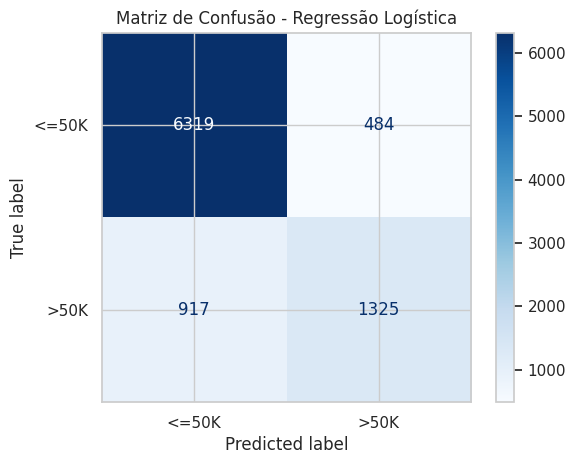

In [36]:
y_pred_log = modelo_lr.predict(X_test) # Fazendo previsões com dados que o Modelo nunca viu
cm_log = confusion_matrix(y_test, y_pred_log) # Matriz comparando resultado esperado com previsões

plt.figure(figsize=(6, 5))
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['<=50K', '>50K'])
disp_log.plot(cmap='Blues')
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

> Matriz | Random Forest

<Figure size 600x500 with 0 Axes>

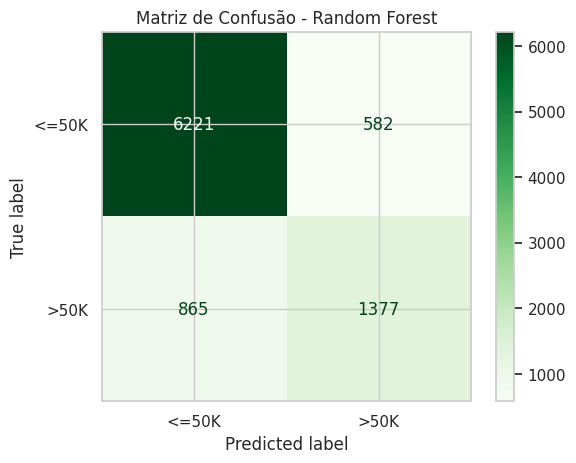

In [37]:
y_pred_rf = modelo_rf.predict(X_test) # Fazendo previsões com dados que o Modelo nunca viu
cm_rf = confusion_matrix(y_test, y_pred_rf) # Matriz comparando resultado esperado com previsões


plt.figure(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['<=50K', '>50K'])
disp_rf.plot(cmap='Greens')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

> Matriz | Gradient Boosting

<Figure size 600x500 with 0 Axes>

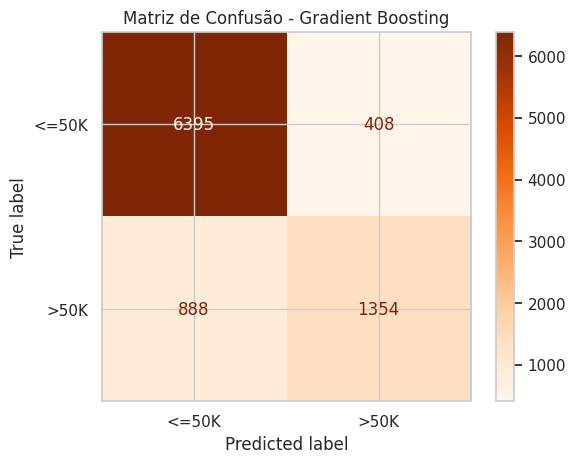

In [38]:
y_pred_gb = modelo_gb.predict(X_test) # Fazendo previsões com dados que o Modelo nunca viu
cm_gb = confusion_matrix(y_test, y_pred_gb) # Matriz comparando resultado esperado com previsões

plt.figure(figsize=(6, 5))
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['<=50K', '>50K'])
disp_gb.plot(cmap='Oranges')
plt.title("Matriz de Confusão - Gradient Boosting")
plt.show()

> # Curva ROC

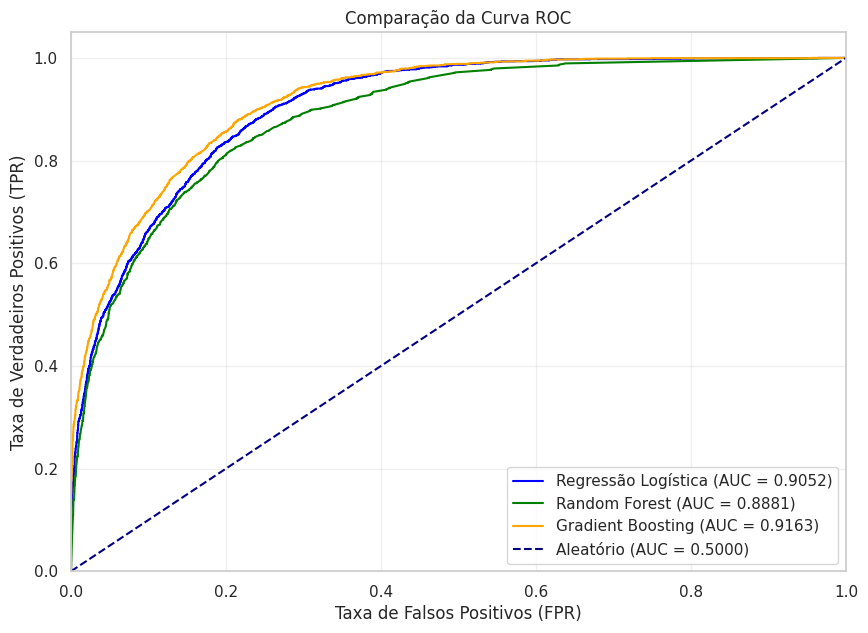

In [39]:
plt.figure(figsize=(10, 7))

modelos = [modelo_lr, modelo_rf, modelo_gb]
nomes = ['Regressão Logística', 'Random Forest', 'Gradient Boosting']
cores = ['blue', 'green', 'orange']

for i, model in enumerate(modelos):
    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, color=cores[i], label=f'{nomes[i]} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Aleatório (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Comparação da Curva ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, nome in zip(modelos, nomes):
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    print(f"{nome}:")
    print(f"  Acurácias: {scores}")
    print(f"  Média: {scores.mean():.4f}")
    print(f"  Desvio padrão: {scores.std():.4f}\n")

Regressão Logística:
  Acurácias: [0.84890363 0.85093053 0.85590566 0.85753778 0.85127165]
  Média: 0.8529
  Desvio padrão: 0.0033

Random Forest:
  Acurácias: [0.8511148  0.83766353 0.84503409 0.8472171  0.84518983]
  Média: 0.8452
  Desvio padrão: 0.0044

Gradient Boosting:
  Acurácias: [0.863829   0.86143357 0.86493459 0.86583118 0.8641725 ]
  Média: 0.8640
  Desvio padrão: 0.0015



> # Feature Importance

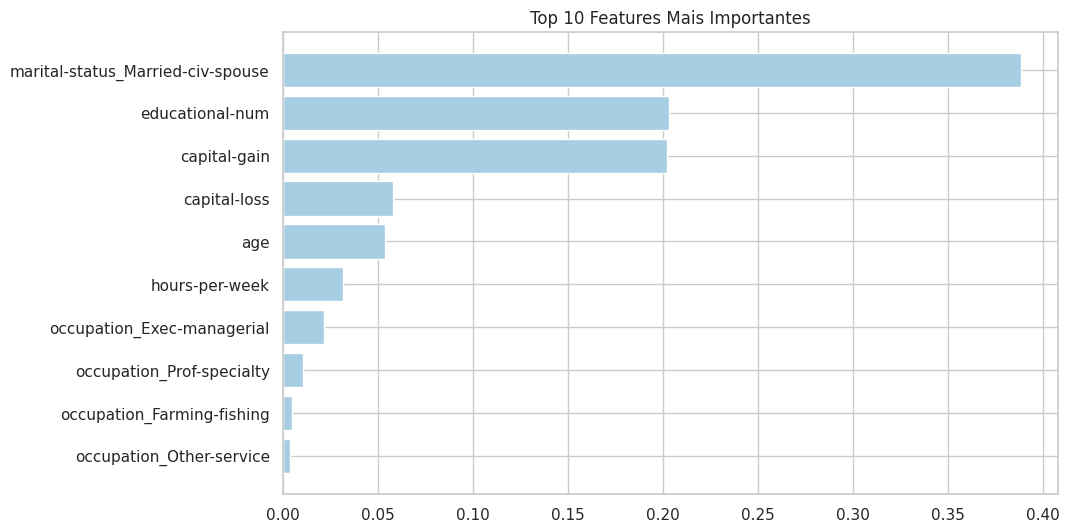

In [41]:
importances = modelo_gb.feature_importances_ # Atributo do modelo Gradient Boosting

features = X_train.columns # Nome das colunas dos nosso dados de treino

df_importances = pd.DataFrame({'importance': importances, 'feature': features}).sort_values(by='importance', ascending=False) # Transforma em DataFrame ordenado por 'Importance'

plt.figure(figsize=(10,6))
plt.barh(df_importances['feature'][:10], df_importances['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Mais Importantes")
plt.show()


# **Etapa 6 | Análise Comparativa**

Com base nos resultados obtidos na etapa de comparação de modelos, foi possível analisar o desempenho dos algoritmos Regressão Logística, Random Forest e Gradient Boosting na tarefa de classificação de renda.

Inicialmente, observamos que todos os modelos apresentaram bons resultados gerais, com métricas equilibradas entre accuracy, precision, recall e F1-score, indicando que o pré-processamento e a seleção de features foram eficazes.

A Regressão Logística apresentou um desempenho consistente, com métricas equilibradas. Por ser um modelo mais simples e linear, teve boa capacidade de generalização, mas pode ter dificuldade em capturar relações mais complexas entre as variáveis.

Já o Random Forest apresentou melhora em relação à Regressão Logística, principalmente em métricas como recall e F1-score, indicando maior capacidade de identificar corretamente os casos positivos (pessoas com renda >50K). Isso ocorre porque o modelo é baseado em múltiplas árvores de decisão, conseguindo capturar melhor padrões não lineares no conjunto de dados.

No conjunto de validação, o modelo de Gradient Boosting apresentou o melhor desempenho geral entre os três algoritmos, especialmente na métrica AUC-ROC, indicando maior capacidade de separação entre as classes. Os resultados foram consistentes com os observados na validação cruzada, onde o modelo também apresentou a maior média de acurácia e baixo desvio padrão entre os folds.

A análise da curva ROC reforça esse resultado, onde o Gradient Boosting se destaca por estar mais próximo do canto superior esquerdo do gráfico, indicando melhor performance na distinção entre classes.

As matrizes de confusão também evidenciam que os modelos baseados em árvores (Random Forest e Gradient Boosting) apresentam menor quantidade de erros, principalmente falsos negativos, que são críticos nesse tipo de problema.


**Feature Importance**

As variáveis mais impactantes na predição foram o estado civil (Married-civ-spouse), ganho de capital (Capital Gain) e nível educacional (Education Num). Isso reforça que fatores socioeconômicos e de investimento são os principais divisores de renda.

## Resultados da Validação Cruzada
-----

A validação cruzada foi utilizada para avaliar a estabilidade dos modelos durante o treinamento.

Os resultados mostraram que o Gradient Boosting apresentou a maior média de acurácia e baixo desvio padrão entre os folds, indicando boa capacidade de generalização e menor sensibilidade à divisão dos dados.

## Resultados da Validação
-----
Após a etapa de validação cruzada, os modelos foram avaliados no conjunto de validação.

Nessa etapa, o Gradient Boosting também apresentou os melhores resultados em Accuracy, Precision, Recall, F1-Score e AUC-ROC, sendo selecionado como modelo final.

## Resultados do Teste Final
------

Por fim, o modelo selecionado foi avaliado no conjunto de teste, composto por dados não utilizados durante o treinamento nem durante a seleção do modelo.

Os resultados confirmaram o desempenho observado anteriormente, demonstrando boa capacidade de generalização.

**Interpretação de Impacto: Idade e Educação**
------

• Impacto da Educação: A cada incremento na variável ‘education_num’, observa-se um aumento linear na probabilidade de alta renda. O "salto" mais significativo ocorre com individuos que possuem Bacharelado, confirmando que o ensino superior é o divisor de águas no mercado de trabalho.

• Impacto da Idade: O modelo identificou um ciclo de vida profissiona. A idade contribui positivamente para a renda até a faixa dos 45-50 anos, Após este ponto, o impacto tende a estabilizar ou declinar levemente.

**Discussão de Viés**

Observou-se que o modelo pode reproduzir vieses históricos presentes nos dados, especialmente relacionados a gênero e ocupação. É fundamental notar que a acurácia elevada não elimina a necessidade de uma análise ética sobre como essas variáveis influenciam as decisões automatizadas, pois o modelo poderia perpetuar desigualdades baseado em vieses de sexo e grupos minoritários somente baseado nos vieses sistêmicos dos dados de treinamento.

> ## Conclusão

Com base em todos os resultados analisados, o modelo de Gradient Boosting se mostrou o mais eficiente para o problema proposto, apresentando melhor desempenho geral e maior capacidade de generalização.

No entanto, a Regressão Logística ainda se destaca pela simplicidade e interpretabilidade, sendo uma boa opção em cenários onde explicabilidade é mais importante que performance máxima.

O Random Forest se posiciona como um meio-termo, oferecendo bom desempenho e maior robustez em relação a modelos lineares.

----
## Exportando o modelo final
---


In [42]:
import joblib

joblib.dump(modelo_gb, 'modelo_final.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [43]:
modelo = joblib.load('modelo_final.joblib')

In [44]:
joblib.dump(X_train.columns.tolist(), 'colunas_modelo.joblib')

['colunas_modelo.joblib']